# Part 1: Building and Understanding GANs from Scratch

### Overview
This section focuses on implementing a Generative Adversarial Network (GAN) from scratch using PyTorch to model simple synthetic 2D data distributions. The aim is to build a strong conceptual understanding of GAN training dynamics before moving to more complex image-based tasks.

### Objective
To develop an intuitive and practical understanding of GANs by training models on low-dimensional data and analysing their ability to learn underlying distributions.

### Tasks Performed
- Reproduced a baseline GAN to model a sine-wave distribution  
- Designed and generated an additional 2D dataset (e.g., spiral / mixture of Gaussians / noisy curve)  
- Trained GAN models to learn these distributions  
- Modified network architecture (e.g., activation functions, layer depth)  
- Visually compared real vs generated samples to assess learning quality  

### Key Insight
Working with simple 2D data allows clear visualisation of how the generator learns data distributions and how architectural changes impact GAN performance and stability.


In [1]:
# ============================================================
# CELL 1 — IMPORTS AND GLOBAL STYLING
# ============================================================
"""
Import all libraries needed for synthetic data generation, GAN training,
result saving, and visualisation. The plotting style is also defined here
so every figure stays consistent and avoids blue colours across the assignment.
"""

import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset


# -----------------------------
# Global plotting style
# -----------------------------
# Blue is avoided completely, as requested.
COLORS = {
    "real": "#F4A261",        # warm orange
    "fake": "#E76F51",        # coral
    "loss_g": "#D81B60",      # pink
    "loss_d": "#F4B400",      # yellow-gold
    "baseline": "#FB8500",    # orange
    "modified": "#C2185B",    # magenta
    "grid": "#D9D9D9",
    "text": "#3A3A3A"
}

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["grid.color"] = COLORS["grid"]
plt.rcParams["axes.labelcolor"] = COLORS["text"]
plt.rcParams["xtick.color"] = COLORS["text"]
plt.rcParams["ytick.color"] = COLORS["text"]
plt.rcParams["text.color"] = COLORS["text"]


In [2]:
# ============================================================
# CELL 2 — CONFIGURATION AND OUTPUT FOLDERS
# ============================================================
"""
Store all experiment settings in one place so Part 1 is easy to reproduce
and adjust. This cell also creates a clean output structure outside the
Notebook folder, with separate folders for plots and tables.
"""

from pathlib import Path

CONFIG = {
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",

    # Data settings
    "n_samples": 2000,
    "batch_size": 128,

    # Latent space
    "z_dim": 4,

    # Model width
    "baseline_hidden_dim": 48,
    "modified_hidden_dim": 80,

    # Optimisation
    "lr": 0.0002,
    "betas": (0.5, 0.999),

    # Epochs
    "sine_epochs": 500,
    "spiral_epochs": 800,
    "modified_spiral_epochs": 800,

    # Plot settings
    "dpi": 300
}

# ------------------------------------------------------------
# Build project paths relative to the notebook location
# ------------------------------------------------------------
# Expected notebook location:
# .../Generative modelling case study/Notebook
#
# Desired output location:
# .../Generative modelling case study/Outputs/Part1_outputs
# .../Generative modelling case study/Outputs/Part2_outputs
# ------------------------------------------------------------

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
OUTPUTS_ROOT = PROJECT_ROOT / "Outputs"

PART1_OUTPUT_DIR = OUTPUTS_ROOT / "Part1_outputs"
PART1_PLOTS_DIR = PART1_OUTPUT_DIR / "plots"
PART1_TABLES_DIR = PART1_OUTPUT_DIR / "tables"

PART2_OUTPUT_DIR = OUTPUTS_ROOT / "Part2_outputs"
PART2_PLOTS_DIR = PART2_OUTPUT_DIR / "plots"
PART2_TABLES_DIR = PART2_OUTPUT_DIR / "tables"

# Create folders
OUTPUTS_ROOT.mkdir(parents=True, exist_ok=True)
PART1_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PART1_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
PART1_TABLES_DIR.mkdir(parents=True, exist_ok=True)

# Part 2 folders are created now as well for clean project structure
PART2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PART2_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
PART2_TABLES_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device(CONFIG["device"])

print(f"Using device: {device}")
print(f"Notebook directory : {NOTEBOOK_DIR}")
print(f"Project root       : {PROJECT_ROOT}")
print(f"Outputs root       : {OUTPUTS_ROOT}")
print(f"Part 1 output dir  : {PART1_OUTPUT_DIR}")
print(f"Part 1 plots dir   : {PART1_PLOTS_DIR}")
print(f"Part 1 tables dir  : {PART1_TABLES_DIR}")
print(f"Part 2 output dir  : {PART2_OUTPUT_DIR}")

Using device: cpu
Notebook directory : c:\Users\girid\OneDrive\Desktop\Generative modelling case study\Notebook
Project root       : c:\Users\girid\OneDrive\Desktop\Generative modelling case study
Outputs root       : c:\Users\girid\OneDrive\Desktop\Generative modelling case study\Outputs
Part 1 output dir  : c:\Users\girid\OneDrive\Desktop\Generative modelling case study\Outputs\Part1_outputs
Part 1 plots dir   : c:\Users\girid\OneDrive\Desktop\Generative modelling case study\Outputs\Part1_outputs\plots
Part 1 tables dir  : c:\Users\girid\OneDrive\Desktop\Generative modelling case study\Outputs\Part1_outputs\tables
Part 2 output dir  : c:\Users\girid\OneDrive\Desktop\Generative modelling case study\Outputs\Part2_outputs


In [3]:
# ============================================================
# CELL 3 — REPRODUCIBILITY UTILITIES
# ============================================================
"""
Fix the random seed so the GAN experiments are reproducible. This makes
the generated outputs, training curves, and model comparisons easier to
trust and easier to explain when discussing results in the report.
"""

def set_seed(seed: int = 42) -> None:
    """
    Fix random seeds for reproducible GAN training.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])

In [4]:
# ============================================================
# CELL 4 — SYNTHETIC DATA GENERATION
# ============================================================
"""
Create the two synthetic datasets used in Part 1. The sine-wave data
reproduces the tutorial example, while the spiral data provides a more
challenging distribution for testing the GAN and its architecture changes.
"""

def generate_sine_data(n_samples: int = 2000, noise_std: float = 0.10) -> np.ndarray:
    """
    Create the noisy sine-wave data used to reproduce the tutorial example.
    This acts as the baseline 2D distribution before moving to the harder spiral task.
    """
    x = np.random.uniform(-math.pi, math.pi, n_samples)
    y = np.sin(x) + noise_std * np.random.randn(n_samples)
    return np.column_stack([x, y]).astype(np.float32)


def generate_spiral_data(n_samples: int = 2000, noise_std: float = 0.08) -> np.ndarray:
    """
    Create the noisy spiral data used as the second Part 1 distribution.
    This is harder than the sine-wave because the model must learn curvature and radial structure.
    """
    t = np.linspace(0, 4 * math.pi, n_samples)
    r = np.linspace(0.1, 1.0, n_samples)

    x = r * np.cos(t) + noise_std * np.random.randn(n_samples)
    y = r * np.sin(t) + noise_std * np.random.randn(n_samples)

    return np.column_stack([x, y]).astype(np.float32)


def make_dataloader(data: np.ndarray, batch_size: int = 128) -> DataLoader:
    """
    Convert the NumPy dataset into a PyTorch DataLoader for training.
    This keeps batching and shuffling consistent across all Part 1 experiments.
    """
    tensor_data = torch.tensor(data, dtype=torch.float32)
    dataset = TensorDataset(tensor_data)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [5]:
# ============================================================
# CELL 5 — FILE PATH HELPERS
# ============================================================
"""
Create small helper functions for saving outputs in the correct folders.
This keeps the main code cleaner and ensures plots and CSV files are
stored separately inside the Part 1 output directory.
"""

def plot_path(filename: str) -> Path:
    """
    Build the full save path for a plot inside the Part 1 plots folder.
    """
    return PART1_PLOTS_DIR / filename


def table_path(filename: str) -> Path:
    """
    Build the full save path for a CSV file inside the Part 1 tables folder.
    """
    return PART1_TABLES_DIR / filename

In [6]:
# ============================================================
# CELL 6 — PLOTTING FUNCTIONS
# ============================================================
"""
Define all plotting functions used in Part 1. These functions keep the
figures consistent, readable, and properly named so they are easy to
find later when selecting the best visuals for the report.
"""

def save_scatter_plot(
    data: np.ndarray,
    title: str,
    filename: str,
    color: str,
    alpha: float = 0.65
) -> None:
    """
    Save a single 2D scatter plot for real or generated samples.
    """
    plt.figure(figsize=(6, 6))
    plt.scatter(data[:, 0], data[:, 1], s=10, alpha=alpha, color=color, edgecolors="none")
    plt.title(title, fontsize=13, fontweight="bold")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.savefig(plot_path(filename), dpi=CONFIG["dpi"], bbox_inches="tight")
    plt.show()


def save_overlay_plot(
    real_data: np.ndarray,
    fake_data: np.ndarray,
    title: str,
    filename: str
) -> None:
    """
    Save an overlay plot to compare real samples with generated samples.
    This is one of the most useful figures for discussing model quality.
    """
    plt.figure(figsize=(6, 6))
    plt.scatter(real_data[:, 0], real_data[:, 1], s=10, alpha=0.38, color=COLORS["real"], label="Real", edgecolors="none")
    plt.scatter(fake_data[:, 0], fake_data[:, 1], s=10, alpha=0.38, color=COLORS["fake"], label="Generated", edgecolors="none")
    plt.title(title, fontsize=13, fontweight="bold")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.savefig(plot_path(filename), dpi=CONFIG["dpi"], bbox_inches="tight")
    plt.show()


def save_loss_plot(
    g_losses: list,
    d_losses: list,
    title: str,
    filename: str
) -> None:
    """
    Save the generator and discriminator loss curves for one experiment.
    These plots help show whether adversarial training stayed reasonably stable.
    """
    plt.figure(figsize=(8, 4))
    plt.plot(g_losses, color=COLORS["loss_g"], linewidth=2.2, label="Generator Loss")
    plt.plot(d_losses, color=COLORS["loss_d"], linewidth=2.2, label="Discriminator Loss")
    plt.title(title, fontsize=13, fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.savefig(plot_path(filename), dpi=CONFIG["dpi"], bbox_inches="tight")
    plt.show()


def save_three_way_comparison(
    real_data: np.ndarray,
    baseline_fake: np.ndarray,
    modified_fake: np.ndarray,
    filename: str
) -> None:
    """
    Save the final three-panel comparison for the spiral experiment.
    This figure directly supports the architecture comparison required in Part 1.
    """
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.scatter(real_data[:, 0], real_data[:, 1], s=10, alpha=0.65, color=COLORS["real"], edgecolors="none")
    plt.title("Real Spiral", fontweight="bold")
    plt.xlabel("x")
    plt.ylabel("y")

    plt.subplot(1, 3, 2)
    plt.scatter(baseline_fake[:, 0], baseline_fake[:, 1], s=10, alpha=0.65, color=COLORS["baseline"], edgecolors="none")
    plt.title("Baseline GAN", fontweight="bold")
    plt.xlabel("x")
    plt.ylabel("y")

    plt.subplot(1, 3, 3)
    plt.scatter(modified_fake[:, 0], modified_fake[:, 1], s=10, alpha=0.65, color=COLORS["modified"], edgecolors="none")
    plt.title("Modified GAN", fontweight="bold")
    plt.xlabel("x")
    plt.ylabel("y")

    plt.tight_layout()
    plt.savefig(plot_path(filename), dpi=CONFIG["dpi"], bbox_inches="tight")
    plt.show()

In [7]:
# ============================================================
# CELL 7 — PART 1 SUMMARY TABLE HELPERS
# ============================================================
"""
Create simple numerical summaries so Part 1 is not judged only by visuals.
These tables compare the real and generated distributions using basic
statistics that are easy to interpret in the report discussion.
"""

def summarise_distribution(real_data: np.ndarray, fake_data: np.ndarray, experiment_name: str) -> pd.DataFrame:
    """
    Compare real and generated samples using mean and standard deviation.
    This gives a small numerical check to support the visual comparisons.
    """
    summary = pd.DataFrame({
        "experiment": [experiment_name] * 4,
        "metric": ["mean_x", "mean_y", "std_x", "std_y"],
        "real": [
            real_data[:, 0].mean(),
            real_data[:, 1].mean(),
            real_data[:, 0].std(),
            real_data[:, 1].std()
        ],
        "generated": [
            fake_data[:, 0].mean(),
            fake_data[:, 1].mean(),
            fake_data[:, 0].std(),
            fake_data[:, 1].std()
        ]
    })
    summary["absolute_difference"] = (summary["real"] - summary["generated"]).abs()
    return summary


def save_summary_table(df: pd.DataFrame, filename: str) -> None:
    """
    Save a Part 1 summary table as a CSV file inside the tables folder.
    This keeps the numerical outputs separate from the figure outputs.
    """
    df.to_csv(table_path(filename), index=False)

In [8]:
# ============================================================
# CELL 8 — MODEL DEFINITIONS
# ============================================================
"""
Define the baseline GAN and the modified GAN used in Part 1. The baseline
model stays simple for the tutorial-style experiments, while the modified
version adds capacity and different activations for direct comparison.
"""

class Generator(nn.Module):
    """
    Build the baseline generator used for the sine-wave and spiral experiments.
    It maps a latent vector into a synthetic 2D point.
    """
    def __init__(self, z_dim: int = 4, hidden_dim: int = 48):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(z_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.network(z)


class Discriminator(nn.Module):
    """
    Build the baseline discriminator that predicts whether a 2D point is real or fake.
    This is the standard companion model for the baseline generator.
    """
    def __init__(self, hidden_dim: int = 48):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


class ModifiedGenerator(nn.Module):
    """
    Build the modified generator with extra depth, BatchNorm, and LeakyReLU.
    This version is used to test whether the harder spiral distribution can be learned more clearly.
    """
    def __init__(self, z_dim: int = 4, hidden_dim: int = 80):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(z_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.network(z)


class ModifiedDiscriminator(nn.Module):
    """
    Build the modified discriminator with extra width and LeakyReLU activations.
    This creates a fairer architecture comparison for the second spiral experiment.
    """
    def __init__(self, hidden_dim: int = 80):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

In [9]:
# ============================================================
# CELL 9 — TRAINING UTILITIES
# ============================================================
"""
Store the training logic for the GAN experiments in one place. The loop
alternates between discriminator and generator updates and records the
losses so each experiment can be evaluated in a consistent way.
"""

def sample_noise(batch_size: int, z_dim: int, device: torch.device) -> torch.Tensor:
    """
    Sample latent noise from a standard normal distribution.
    These noise vectors act as the generator input during GAN training.
    """
    return torch.randn(batch_size, z_dim, device=device)


def train_gan(
    generator: nn.Module,
    discriminator: nn.Module,
    dataloader: DataLoader,
    epochs: int,
    z_dim: int,
    lr: float,
    betas: tuple,
    device: torch.device,
    print_every: int = 100
):
    """
    Train one GAN experiment and record the loss history.
    The same routine is reused for the sine-wave, baseline spiral, and modified spiral runs.
    """
    criterion = nn.BCELoss()

    g_optimizer = optim.Adam(generator.parameters(), lr=lr, betas=betas)
    d_optimizer = optim.Adam(discriminator.parameters(), lr=lr, betas=betas)

    generator.to(device)
    discriminator.to(device)

    g_losses = []
    d_losses = []

    for epoch in range(epochs):
        g_epoch_loss = 0.0
        d_epoch_loss = 0.0

        for (real_batch,) in dataloader:
            real_batch = real_batch.to(device)
            batch_size = real_batch.size(0)

            real_labels = torch.ones(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            # Train the discriminator on real and fake samples.
            d_optimizer.zero_grad()

            real_preds = discriminator(real_batch)
            real_loss = criterion(real_preds, real_labels)

            z = sample_noise(batch_size, z_dim, device)
            fake_batch = generator(z)
            fake_preds = discriminator(fake_batch.detach())
            fake_loss = criterion(fake_preds, fake_labels)

            d_loss = real_loss + fake_loss
            d_loss.backward()
            d_optimizer.step()

            # Train the generator to fool the discriminator.
            g_optimizer.zero_grad()

            z = sample_noise(batch_size, z_dim, device)
            generated_batch = generator(z)
            preds = discriminator(generated_batch)

            g_loss = criterion(preds, real_labels)
            g_loss.backward()
            g_optimizer.step()

            g_epoch_loss += g_loss.item()
            d_epoch_loss += d_loss.item()

        g_losses.append(g_epoch_loss / len(dataloader))
        d_losses.append(d_epoch_loss / len(dataloader))

        if (epoch + 1) % print_every == 0:
            print(
                f"Epoch [{epoch+1:>3}/{epochs}] "
                f"| D Loss: {d_losses[-1]:.4f} "
                f"| G Loss: {g_losses[-1]:.4f}"
            )

    return generator, discriminator, g_losses, d_losses


def generate_samples(
    generator: nn.Module,
    n_samples: int,
    z_dim: int,
    device: torch.device
) -> np.ndarray:
    """
    Generate synthetic 2D points using a trained generator.
    These samples are later compared against the real dataset visually and numerically.
    """
    generator.eval()
    with torch.no_grad():
        z = sample_noise(n_samples, z_dim, device)
        fake_data = generator(z).cpu().numpy()
    return fake_data

In [10]:
# ============================================================
# CELL 10 — EXPERIMENT RUNNER
# ============================================================
"""
Create one reusable pipeline for running each Part 1 experiment. This keeps
training, figure saving, and table saving consistent and makes the notebook
much easier to read when returning to it during report writing.
"""

def run_experiment(
    experiment_name: str,
    real_data: np.ndarray,
    generator: nn.Module,
    discriminator: nn.Module,
    epochs: int,
    prefix: str,
    generated_color: str,
    overlay_generated_color: str
):
    """
    Run one full GAN experiment from training through to saved outputs.
    This function saves the real plot, generated plot, overlay, loss curves, and summary table.
    """
    print("\n" + "=" * 72)
    print(f"RUNNING: {experiment_name}")
    print("=" * 72)

    dataloader = make_dataloader(real_data, batch_size=CONFIG["batch_size"])

    save_scatter_plot(
        data=real_data,
        title=f"{experiment_name} — Real Samples",
        filename=f"{prefix}_real_samples.png",
        color=COLORS["real"]
    )

    generator, discriminator, g_losses, d_losses = train_gan(
        generator=generator,
        discriminator=discriminator,
        dataloader=dataloader,
        epochs=epochs,
        z_dim=CONFIG["z_dim"],
        lr=CONFIG["lr"],
        betas=CONFIG["betas"],
        device=device,
        print_every=100
    )

    fake_data = generate_samples(
        generator=generator,
        n_samples=len(real_data),
        z_dim=CONFIG["z_dim"],
        device=device
    )

    save_scatter_plot(
        data=fake_data,
        title=f"{experiment_name} — Generated Samples",
        filename=f"{prefix}_generated_samples.png",
        color=generated_color
    )

    # Use the generic overlay plot but keep filenames very clear.
    save_overlay_plot(
        real_data=real_data,
        fake_data=fake_data,
        title=f"{experiment_name} — Real vs Generated",
        filename=f"{prefix}_real_vs_generated.png"
    )

    save_loss_plot(
        g_losses=g_losses,
        d_losses=d_losses,
        title=f"{experiment_name} — Loss Curves",
        filename=f"{prefix}_loss_curves.png"
    )

    summary_df = summarise_distribution(
        real_data=real_data,
        fake_data=fake_data,
        experiment_name=experiment_name
    )
    save_summary_table(summary_df, f"{prefix}_summary_table.csv")

    return fake_data, g_losses, d_losses, summary_df


RUNNING: Baseline GAN on Sine-Wave Data


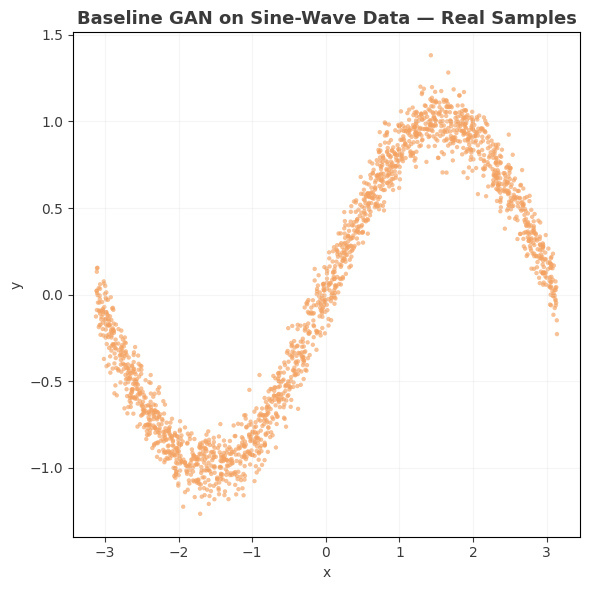

Epoch [100/500] | D Loss: 1.3766 | G Loss: 0.7145
Epoch [200/500] | D Loss: 1.3851 | G Loss: 0.6953
Epoch [300/500] | D Loss: 1.3866 | G Loss: 0.6915
Epoch [400/500] | D Loss: 1.3874 | G Loss: 0.6923
Epoch [500/500] | D Loss: 1.3874 | G Loss: 0.6944


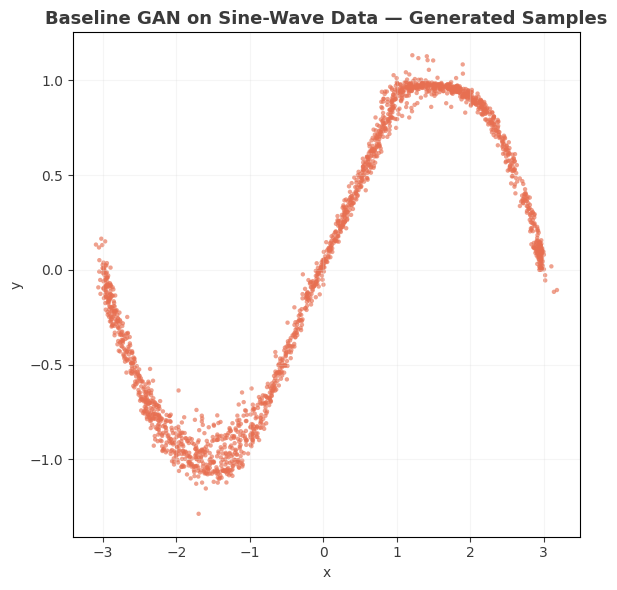

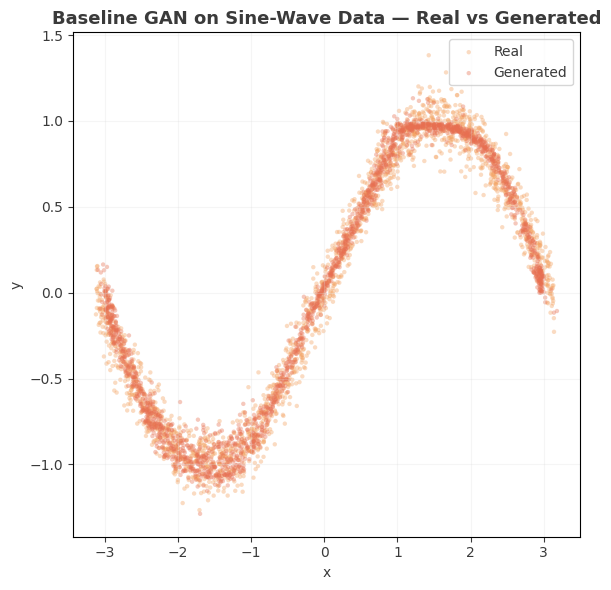

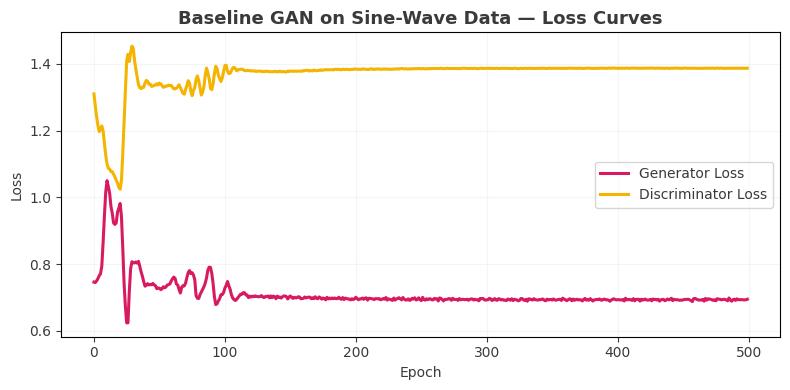


Sine-wave summary:
                       experiment  metric      real  generated  \
0  Baseline GAN on Sine-Wave Data  mean_x -0.008564  -0.074429   
1  Baseline GAN on Sine-Wave Data  mean_y  0.010462   0.004920   
2  Baseline GAN on Sine-Wave Data   std_x  1.835556   1.834331   
3  Baseline GAN on Sine-Wave Data   std_y  0.712926   0.713843   

   absolute_difference  
0             0.065865  
1             0.005542  
2             0.001225  
3             0.000917  


In [11]:
# ============================================================
# CELL 11 — EXPERIMENT A: BASELINE GAN ON SINE-WAVE DATA
# ============================================================
"""
Run the sine-wave experiment used to reproduce the tutorial example. This
acts as the baseline Part 1 task and checks whether the GAN can learn
a smooth nonlinear 2D manifold before moving to the harder spiral task.
"""

sine_data = generate_sine_data(
    n_samples=CONFIG["n_samples"],
    noise_std=0.10
)

baseline_sine_fake, g_loss_sine, d_loss_sine, summary_sine = run_experiment(
    experiment_name="Baseline GAN on Sine-Wave Data",
    real_data=sine_data,
    generator=Generator(
        z_dim=CONFIG["z_dim"],
        hidden_dim=CONFIG["baseline_hidden_dim"]
    ),
    discriminator=Discriminator(
        hidden_dim=CONFIG["baseline_hidden_dim"]
    ),
    epochs=CONFIG["sine_epochs"],
    prefix="p1_01_sine_baseline",
    generated_color=COLORS["fake"],
    overlay_generated_color=COLORS["fake"]
)

print("\nSine-wave summary:")
print(summary_sine)


RUNNING: Baseline GAN on Spiral Data


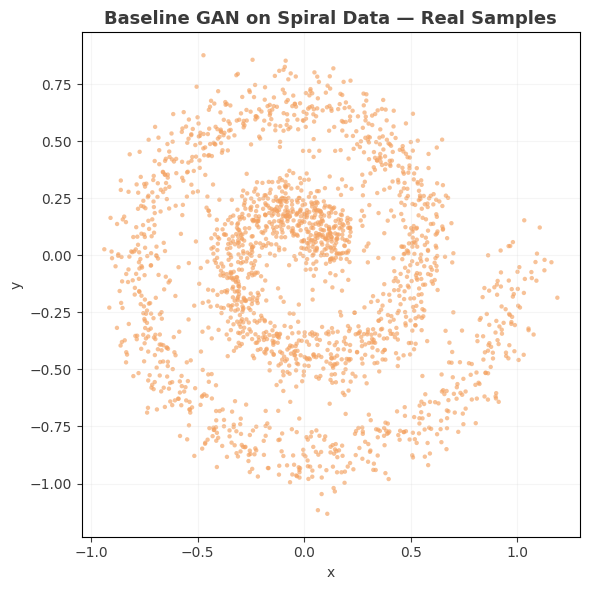

Epoch [100/800] | D Loss: 1.3839 | G Loss: 0.6919
Epoch [200/800] | D Loss: 1.3835 | G Loss: 0.6936
Epoch [300/800] | D Loss: 1.3855 | G Loss: 0.6975
Epoch [400/800] | D Loss: 1.3844 | G Loss: 0.6941
Epoch [500/800] | D Loss: 1.3847 | G Loss: 0.6935
Epoch [600/800] | D Loss: 1.3854 | G Loss: 0.6930
Epoch [700/800] | D Loss: 1.3859 | G Loss: 0.6914
Epoch [800/800] | D Loss: 1.3859 | G Loss: 0.6949


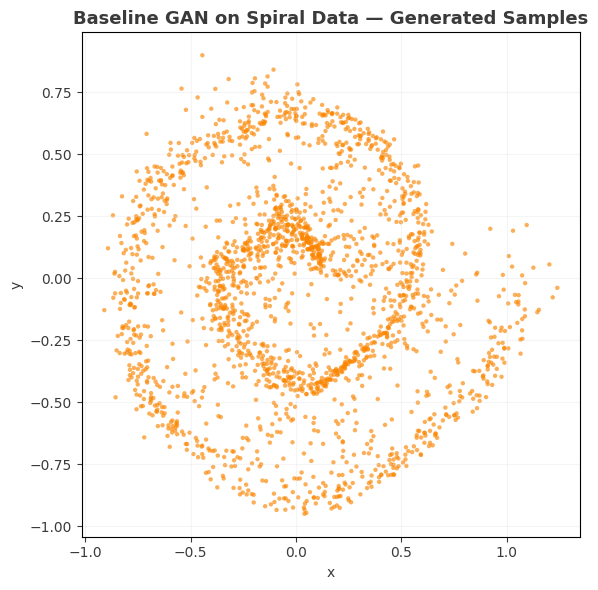

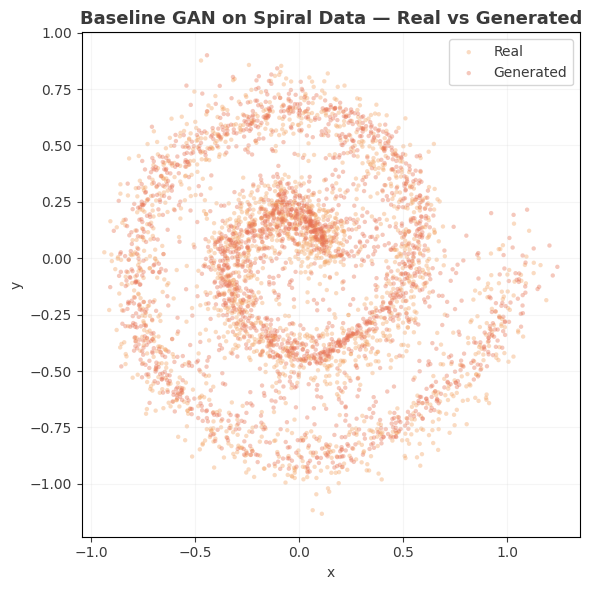

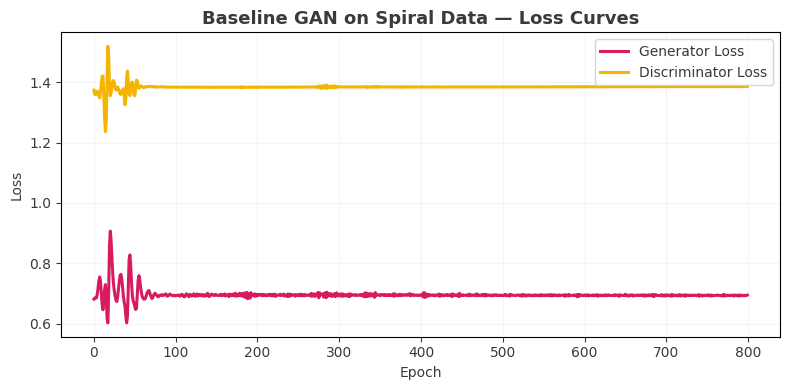


Spiral baseline summary:
                    experiment  metric      real  generated  \
0  Baseline GAN on Spiral Data  mean_x -0.002738   0.006012   
1  Baseline GAN on Spiral Data  mean_y -0.073826  -0.057837   
2  Baseline GAN on Spiral Data   std_x  0.437880   0.440161   
3  Baseline GAN on Spiral Data   std_y  0.428805   0.414769   

   absolute_difference  
0             0.008749  
1             0.015989  
2             0.002281  
3             0.014036  


In [12]:
# ============================================================
# CELL 12 — EXPERIMENT B: BASELINE GAN ON SPIRAL DATA
# ============================================================
"""
Run the baseline GAN on the spiral distribution. This tests whether the
same simple architecture can model a harder 2D shape with curvature,
multiple turns, and broader structural variation.
"""

spiral_data = generate_spiral_data(
    n_samples=CONFIG["n_samples"],
    noise_std=0.08
)

baseline_spiral_fake, g_loss_spiral, d_loss_spiral, summary_spiral = run_experiment(
    experiment_name="Baseline GAN on Spiral Data",
    real_data=spiral_data,
    generator=Generator(
        z_dim=CONFIG["z_dim"],
        hidden_dim=CONFIG["baseline_hidden_dim"]
    ),
    discriminator=Discriminator(
        hidden_dim=CONFIG["baseline_hidden_dim"]
    ),
    epochs=CONFIG["spiral_epochs"],
    prefix="p1_02_spiral_baseline",
    generated_color=COLORS["baseline"],
    overlay_generated_color=COLORS["baseline"]
)

print("\nSpiral baseline summary:")
print(summary_spiral)


RUNNING: Modified GAN on Spiral Data


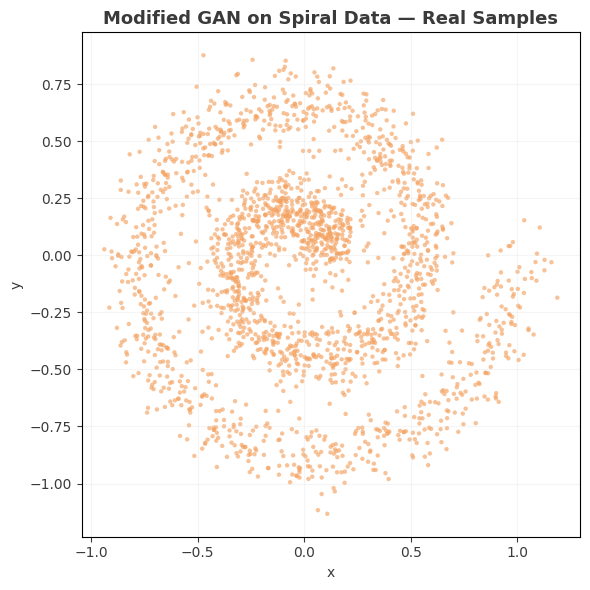

Epoch [100/800] | D Loss: 1.3860 | G Loss: 0.6787
Epoch [200/800] | D Loss: 1.3853 | G Loss: 0.6811
Epoch [300/800] | D Loss: 1.3859 | G Loss: 0.6949
Epoch [400/800] | D Loss: 1.3860 | G Loss: 0.6896
Epoch [500/800] | D Loss: 1.3859 | G Loss: 0.6939
Epoch [600/800] | D Loss: 1.3864 | G Loss: 0.6924
Epoch [700/800] | D Loss: 1.3863 | G Loss: 0.6929
Epoch [800/800] | D Loss: 1.3864 | G Loss: 0.6911


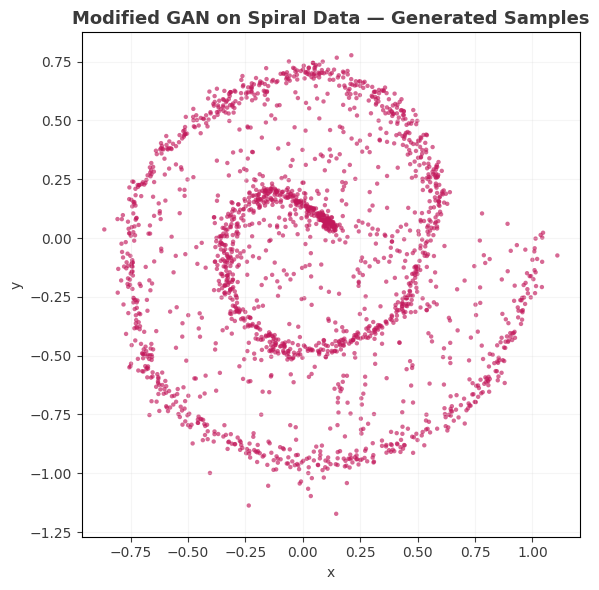

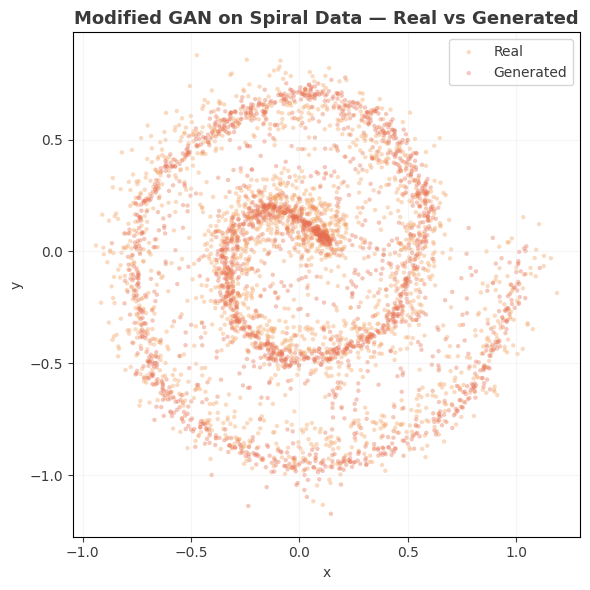

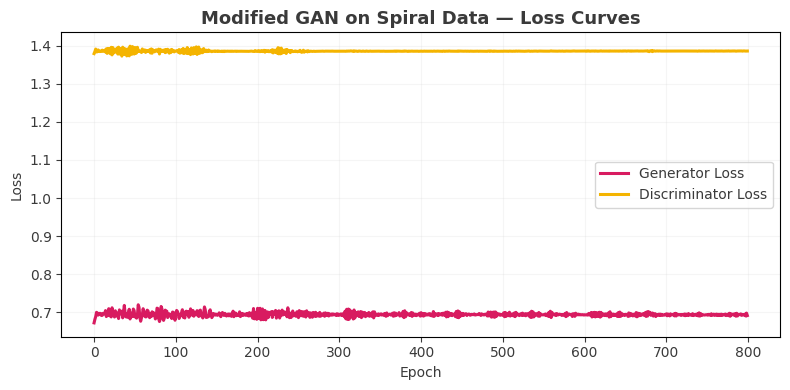


Spiral modified summary:
                    experiment  metric      real  generated  \
0  Modified GAN on Spiral Data  mean_x -0.002738   0.024543   
1  Modified GAN on Spiral Data  mean_y -0.073826  -0.095062   
2  Modified GAN on Spiral Data   std_x  0.437880   0.428272   
3  Modified GAN on Spiral Data   std_y  0.428805   0.458638   

   absolute_difference  
0             0.027281  
1             0.021236  
2             0.009607  
3             0.029833  


In [13]:
# ============================================================
# CELL 13 — EXPERIMENT C: MODIFIED GAN ON SPIRAL DATA
# ============================================================
"""
Run the modified GAN on the same spiral data so the architecture change
can be compared directly against the baseline model. This is the key
experiment for the final comparison required in Part 1.
"""

modified_spiral_fake, g_loss_spiral_mod, d_loss_spiral_mod, summary_spiral_mod = run_experiment(
    experiment_name="Modified GAN on Spiral Data",
    real_data=spiral_data,
    generator=ModifiedGenerator(
        z_dim=CONFIG["z_dim"],
        hidden_dim=CONFIG["modified_hidden_dim"]
    ),
    discriminator=ModifiedDiscriminator(
        hidden_dim=CONFIG["modified_hidden_dim"]
    ),
    epochs=CONFIG["modified_spiral_epochs"],
    prefix="p1_03_spiral_modified",
    generated_color=COLORS["modified"],
    overlay_generated_color=COLORS["modified"]
)

print("\nSpiral modified summary:")
print(summary_spiral_mod)

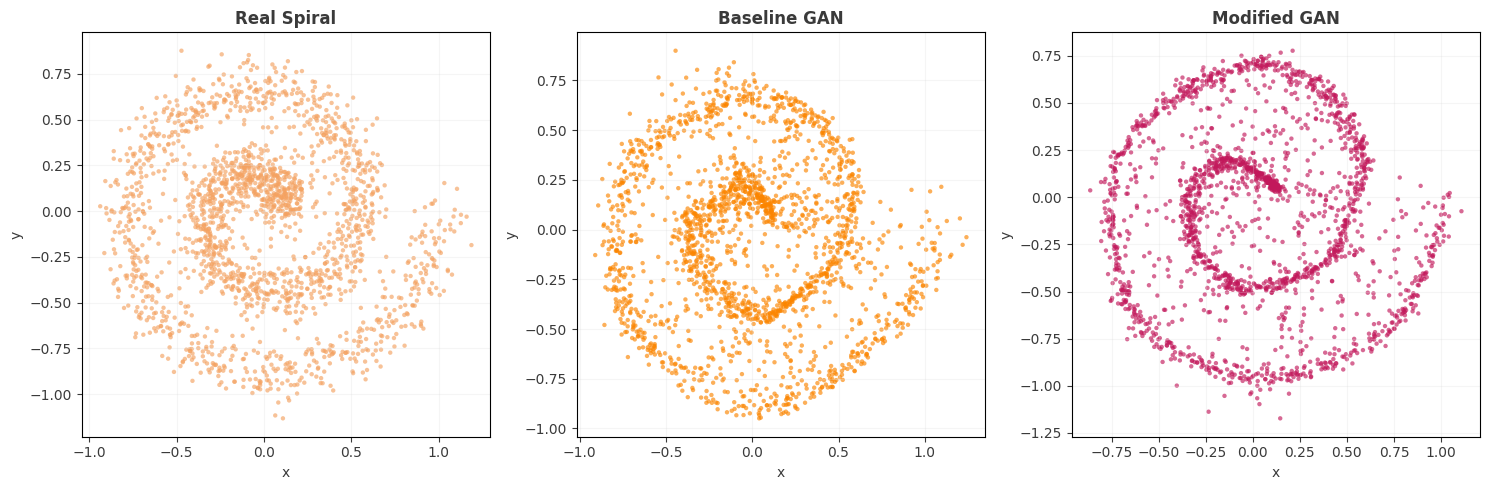


Combined Part 1 summary:
                        experiment  metric      real  generated  \
0   Baseline GAN on Sine-Wave Data  mean_x -0.008564  -0.074429   
1   Baseline GAN on Sine-Wave Data  mean_y  0.010462   0.004920   
2   Baseline GAN on Sine-Wave Data   std_x  1.835556   1.834331   
3   Baseline GAN on Sine-Wave Data   std_y  0.712926   0.713843   
4      Baseline GAN on Spiral Data  mean_x -0.002738   0.006012   
5      Baseline GAN on Spiral Data  mean_y -0.073826  -0.057837   
6      Baseline GAN on Spiral Data   std_x  0.437880   0.440161   
7      Baseline GAN on Spiral Data   std_y  0.428805   0.414769   
8      Modified GAN on Spiral Data  mean_x -0.002738   0.024543   
9      Modified GAN on Spiral Data  mean_y -0.073826  -0.095062   
10     Modified GAN on Spiral Data   std_x  0.437880   0.428272   
11     Modified GAN on Spiral Data   std_y  0.428805   0.458638   

    absolute_difference  
0              0.065865  
1              0.005542  
2              0.001225 

In [14]:
# ============================================================
# CELL 14 — FINAL SPIRAL COMPARISON AND COMBINED TABLE
# ============================================================
"""
Save the final Part 1 comparison outputs. This includes the three-panel
spiral comparison figure and one combined summary table so the most useful
results are easy to locate during report writing.
"""

save_three_way_comparison(
    real_data=spiral_data,
    baseline_fake=baseline_spiral_fake,
    modified_fake=modified_spiral_fake,
    filename="p1_04_spiral_real_vs_baseline_vs_modified.png"
)

combined_summary = pd.concat(
    [summary_sine, summary_spiral, summary_spiral_mod],
    axis=0,
    ignore_index=True
)

save_summary_table(combined_summary, "p1_05_combined_summary_table.csv")

print("\nCombined Part 1 summary:")
print(combined_summary)

print(f"\nAll Part 1 outputs saved to: {PART1_OUTPUT_DIR}")
print(f"Plots folder: {PART1_PLOTS_DIR}")
print(f"Tables folder: {PART1_TABLES_DIR}")

In [15]:
import os
print(os.getcwd())

c:\Users\girid\OneDrive\Desktop\Generative modelling case study\Notebook
